In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open("names.txt", 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
#building the vocab of chs and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
# build the dataset
block_size = 3
X, Y = [], []
for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->' , itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [5]:
X.shape, X.dtype

(torch.Size([228146, 3]), torch.int64)

In [6]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        ...,
        [26, 26, 25],
        [26, 25, 26],
        [25, 26, 24]])

In [7]:
C = torch.randn(27,2)
C[5]

tensor([0.3913, 0.5901])

In [8]:
C[X].shape


torch.Size([228146, 3, 2])

In [9]:
X[15,1]

tensor(22)

In [10]:
C[X][15,1]

tensor([-1.7792,  0.3274])

In [11]:
C[22]

tensor([-1.7792,  0.3274])

In [12]:
emd = C[X]
emd.shape

torch.Size([228146, 3, 2])

In [13]:
# hidden layer
w1 = torch.randn((6,100))
b1 = torch.randn(100)

In [14]:
#emd @ w1 + b1
h = torch.tanh(emd.view(emd.shape[0],6) @ w1 + b1)
#h = emd.view(-1,6) @ w1 + b1, why does this work too
h.shape

torch.Size([228146, 100])

In [15]:
w2 = torch.randn(100, 27)
b2 = torch.randn(27)
w2.shape

torch.Size([100, 27])

In [96]:
logits = h @ w2 + b2
logits.shape

torch.Size([32, 27])

In [97]:
counts = logits.exp()

In [99]:
prob = counts/ counts.sum(1, keepdims = True)
prob.shape

torch.Size([32, 27])

In [110]:
loss = -prob[torch.arange(32), Y].log().mean() 
loss

tensor(19.2445)

In [113]:
loss = F.cross_entropy(logits, Y) # better way, more efficient, fused kernel
# more numerically well-behaved
# offsets, handeling e^ really positive numbers by substracting the max number from the tensor

In [56]:
parameters = [C, w1, b1, w2, b2]


In [57]:
for p in parameters:
    p.requires_grad = True

In [70]:
# the main training loop

for _ in range(10000):
    # forward pass
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
    emd = C[X[ix]] #[32, 3, 2]
    h = torch.tanh(emd.view(-1,6) @ w1 + b1) #[32,100]
    logits = h @ w2 + b2 #[32,27]
    loss = F.cross_entropy(logits, Y[ix])
  

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    for p in parameters:
        p.data -= 0.01 * p.grad

print(loss.item())

2.1726293563842773


In [71]:
emd = C[X] #[32, 3, 2]
h = torch.tanh(emd.view(-1,6) @ w1 + b1) #[32,100]
logits = h @ w2 + b2 #[32,27]
loss = F.cross_entropy(logits, Y)
loss

tensor(2.3196, grad_fn=<NllLossBackward0>)

In [ ]:
Y 

In [76]:
h.shape # hidden activation layer for every pone of our 32  examples
b1.shape # torch broadcasting rules

torch.Size([100])

In [60]:
#torch.cat([emd[: , 0, :],
#emd[: , 1, :],
#emd[: , 2, :]], 1).shape

In [64]:
#torch.cat(torch.unbind(emd,1), 1).shape

In [ ]:
# view
# storage is always a one dim tensor, that's how the computer interprets it 
# with view we can manipulate that 1 dim tensor to make it  interpreted as an N dim tensor


In [66]:
emd.view(32,6).shape

torch.Size([32, 6])

In [72]:
## splitting everything into 3 stages - 

#1. training set -- 80% of dataset

#2. dev/ validation set -- 10% of dataset

#3. testing set -- 10% of dataset

In [67]:
#building the dataset

def build_dataset(words):
    block_size = 3
    X, Y = [], [] 
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int (0.9* len(words))


Xtr, Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182691, 3]) torch.Size([182691])
torch.Size([22793, 3]) torch.Size([22793])
torch.Size([22662, 3]) torch.Size([22662])


In [45]:
Xtr, Ytr = build_dataset(words[:n1])

torch.Size([182484, 3]) torch.Size([182484])


In [18]:
Xtr.shape, Ytr.shape

(torch.Size([182580, 3]), torch.Size([182580]))

In [22]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [23]:
Xdev.shape, Ydev.shape

(torch.Size([22767, 3]), torch.Size([22767]))

In [24]:
Xte.shape, Yte.shape

(torch.Size([22799, 3]), torch.Size([22799]))

In [25]:
len(words)

32033

In [26]:
n1

25626

In [27]:
n2

28829

In [116]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g)
w1 = torch.randn((30, 200), generator=g) 
b1 = torch.randn(200, generator=g)
w2 = torch.randn((200, 27), generator=g) 
b2 = torch.randn(27, generator=g)
parameters = [C, w1, b1, w2, b2]

In [117]:
for p in parameters:
    p.requires_grad = True

In [118]:
stepi = []
lossi = []

In [121]:
# the main training loop

for i in range(50000):
    # forward pass
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emd = C[Xtr[ix]] #[32, 3, 2]
    h = torch.tanh(emd.view(-1,30) @ w1 + b1) #[32,100]
    logits = h @ w2 + b2 #[32,27]
    loss = F.cross_entropy(logits, Ytr[ix])
  

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    for p in parameters:
        p.data -= 0.01 * p.grad

    #stats
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

1.9835926294326782


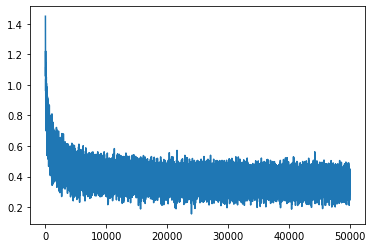

In [120]:
plt.plot(stepi, lossi)

In [122]:
emd = C[Xdev] #[32, 3, 2]
h = torch.tanh(emd.view(-1,30) @ w1 + b1) #[32,100]
logits = h @ w2 + b2 #[32,27]
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2008, grad_fn=<NllLossBackward0>)

In [123]:
emd = C[Xtr] #[32, 3, 2]
h = torch.tanh(emd.view(-1,30) @ w1 + b1) #[32,100]
logits = h @ w2 + b2 #[32,27]
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1716, grad_fn=<NllLossBackward0>)

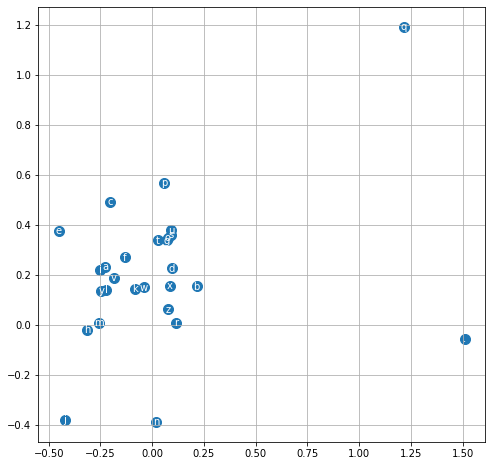

In [124]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=100)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid("minor")

In [126]:
# sample from the model

g = torch.Generator().manual_seed(2147483647 + 10)
for i in range(20):
    out = []
    context = [0] * block_size
    while True:
        emd = C[torch.tensor([context])]
        h = torch.tanh(emd.view(1,-1) @ w1 + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carpah.
ambril.
khirmri.
revty.
skanda.
emmahnen.
amerric.
kaqui.
ner.
kiah.
maiia.
kaleig.
dham.
prin.
quint.
shornea.
jadbi.
wazelo.
dearynix.
kael.
